In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

DATA_FILE = '../data/scenario_6_marina_features_50ms_final.csv'

LOOKAHEAD_WINDOW_MS = 500      # Look 0.5 seconds into the future
DEPLETING_THRESHOLD_MS = -100  # Threshold for 'Depleting'
FILLING_THRESHOLD_MS = 100     # Threshold for 'Filling'

df = pd.read_csv(DATA_FILE)
print(f"Dataset loaded. Shape: {df.shape}")

df.sort_values(['video_id', 'iteration', 'timestamp'], inplace=True)

# Calculate lookahead steps (Window is 50ms, so 500ms = 10 steps)
lookahead_steps = int(LOOKAHEAD_WINDOW_MS / 50)

# Create the target label
# We group by video_id and iteration to prevent looking ahead into a different video session
df['future_buffer'] = df.groupby(['video_id', 'iteration'])['buffer_level_ms'].shift(-lookahead_steps)
df['buffer_change'] = df['future_buffer'] - df['buffer_level_ms']

df.dropna(subset=['future_buffer'], inplace=True)

conditions = [
    df['buffer_change'] < DEPLETING_THRESHOLD_MS,
    df['buffer_change'] > FILLING_THRESHOLD_MS
]
choices = ['Depleting', 'Filling']
df['buffer_state'] = np.select(conditions, choices, default='Steady')

print("\nLabel Distribution:")
print(df['buffer_state'].value_counts(normalize=True))

Dataset loaded. Shape: (163090, 13)

Label Distribution:
buffer_state
Depleting    0.624529
Filling      0.345694
Steady       0.029776
Name: proportion, dtype: float64


In [ ]:

all_features = [
    'packet_count', 
    'ps_sum', 'ps2_sum', 'ps3_sum', 
    'iat_sum', 'iat2_sum', 'iat3_sum',
    "bwe", 'jitter'
]

X = df[all_features]
y = df['buffer_state']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


model_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1
)

print(f"Training Random Forest with {len(all_features)} features...")
model_baseline.fit(X_train, y_train)

# Predictions
y_pred = model_baseline.predict(X_test)

print("\n--- Classification Report (All Features) ---")
print(classification_report(y_test, y_pred))

Training Random Forest with 9 features...

--- Classification Report (All Features) ---
              precision    recall  f1-score   support

   Depleting       0.83      0.72      0.77     25384
     Filling       0.63      0.57      0.60     14051
      Steady       0.10      0.50      0.17      1210

    accuracy                           0.66     40645
   macro avg       0.52      0.60      0.51     40645
weighted avg       0.74      0.66      0.69     40645



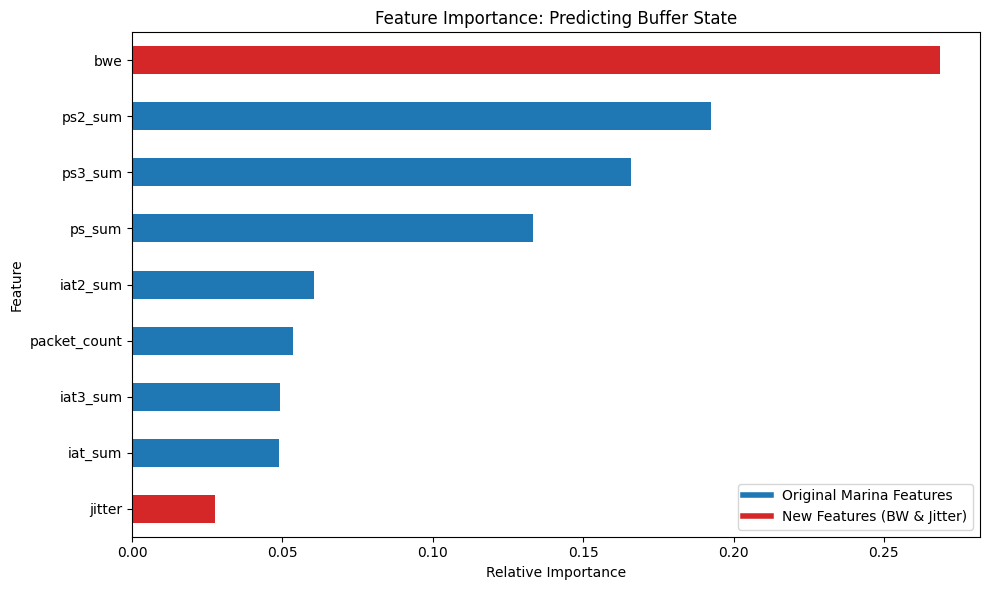


Top 5 Most Important Features:
bwe         0.268541
ps2_sum     0.192519
ps3_sum     0.165812
ps_sum      0.133301
iat2_sum    0.060408
dtype: float64


In [3]:
# --- Feature Importance Visualization ---

importances = pd.Series(model_baseline.feature_importances_, index=all_features)
importances.sort_values(ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
colors = ['#1f77b4' if x not in ['bwe', 'jitter'] else '#d62728' for x in importances.index]

importances.plot(kind='barh', color=colors)
plt.title('Feature Importance: Predicting Buffer State')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')

# Highlight new features in the legend
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='#1f77b4', lw=4),
                Line2D([0], [0], color='#d62728', lw=4)]
plt.legend(custom_lines, ['Original Marina Features', 'New Features (BW & Jitter)'])

plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(importances.sort_values(ascending=False).head(5))

--- Running Comparative Experiments ---
Standard_Marina      -> Depleting Recall: 0.78
Network_QoS_Only     -> Depleting Recall: 0.71
Hybrid_Model         -> Depleting Recall: 0.72
Top_Features         -> Depleting Recall: 0.72
All_Features         -> Depleting Recall: 0.72


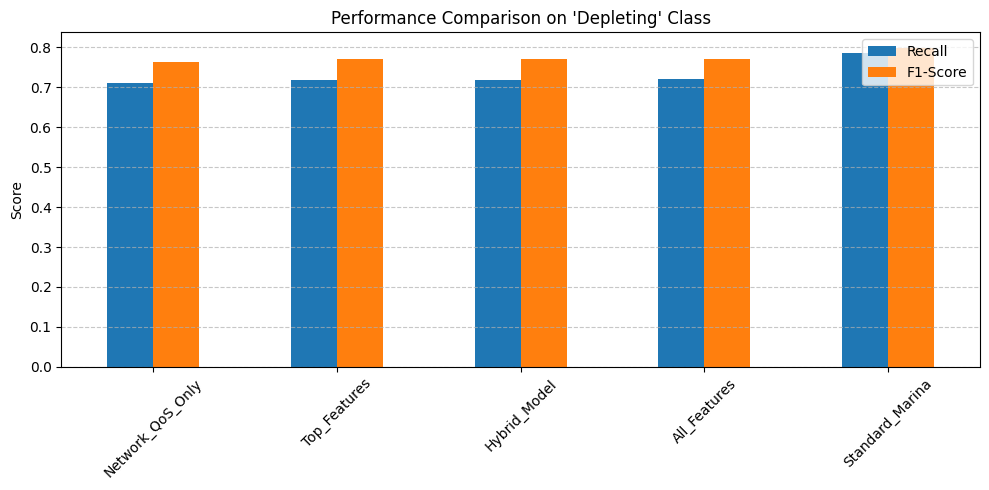

In [ ]:
feature_experiments = {
    "Standard_Marina": ['packet_count', 'ps_sum', 'ps2_sum', 'ps3_sum', 'iat_sum', 'iat2_sum', 'iat3_sum'],
    "Network_QoS_Only": ['bwe', 'jitter'],
    "Hybrid_Model": ['ps_sum', 'iat_sum', 'bwe', 'jitter'],
    "Top_Features": ['bwe','ps_sum'],
    "All_Features": all_features
    
}

results_recall = {}
results_f1 = {}

print("--- Running Comparative Experiments ---")

for name, feats in feature_experiments.items():
    # Subset data
    X_sub = df[feats]
    X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y, test_size=0.25, random_state=42, stratify=y)
    
    # Train
    clf = RandomForestClassifier(max_depth=8, random_state=42, class_weight='balanced', n_jobs=-1)
    clf.fit(X_tr, y_tr)
    
    # Evaluate
    y_p = clf.predict(X_te)
    report = classification_report(y_te, y_p, output_dict=True, zero_division=0)
    
    # Store specific metrics for 'Depleting' (the most critical class)
    if 'Depleting' in report:
        results_recall[name] = report['Depleting']['recall']
        results_f1[name] = report['Depleting']['f1-score']
        print(f"{name.ljust(20)} -> Depleting Recall: {report['Depleting']['recall']:.2f}")

# Plot Results
results_df = pd.DataFrame({'Recall': results_recall, 'F1-Score': results_f1})
results_df.sort_values('Recall', inplace=True)

results_df.plot(kind='bar', figsize=(10, 5))
plt.title("Performance Comparison on 'Depleting' Class")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()